# Regression model   

### Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

### Loading dataset

In [2]:
df = pd.read_csv(r'C:\prerit\Projects\Ride-Sharing-Demand-Intelligence\Processed\Cleaned_yellow_tripdata_2025-01.csv')

df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,extra,...,total_amount,cbd_congestion_fee,trip_duration_min,pickup_hour,pickup_day,pickup_weekday,is_weekend,revenue_per_mile,revenue_per_minute,tip_percentage
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,229,237,1,10.0,3.5,...,18.00,0.0,8.35,0,1,2,0,11.25,2.16,0.30
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,236,237,1,5.1,3.5,...,12.12,0.0,2.55,0,1,2,0,24.24,4.75,0.40
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,141,141,1,5.1,3.5,...,12.10,0.0,1.95,0,1,2,0,20.17,6.21,0.39
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,244,244,2,7.2,1.0,...,9.70,0.0,5.57,0,1,2,0,18.65,1.74,0.00
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,244,116,2,5.8,1.0,...,8.30,0.0,3.53,0,1,2,0,12.58,2.35,0.00


### Feature Selection

In [23]:
features = ["trip_distance", "trip_duration_min"]
target = "fare_amount"

X = df[features]
y = df[target]

### Train-Test split

In [24]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

### Training Linear Regression Model

In [25]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Predictions

In [26]:
y_pred = model.predict(X_test)
y_pred

array([32.87503128, 14.48221886, 35.06455915, ..., 29.40144292,
       42.16129313, 20.51853527], shape=(626565,))

### Evaluating model

In [27]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean absolute error :",mae)
print("r2 score :", r2)

Mean absolute error : 2.32583256179949
r2 score : 0.9239765097004293


In [28]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,trip_distance,3.600227
1,trip_duration_min,0.020281


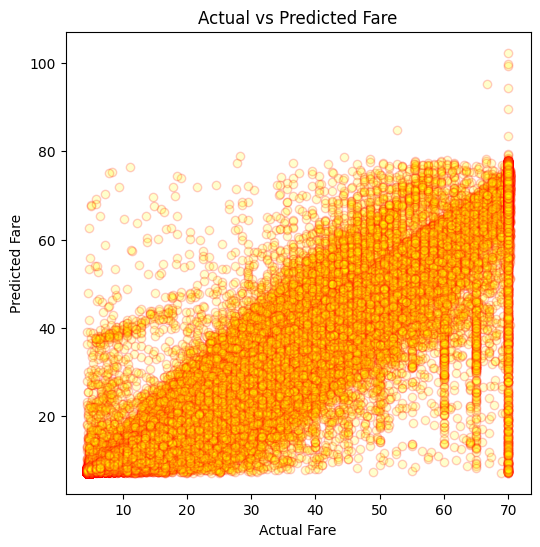

In [29]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.2, color="yellow", edgecolor="red")
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare")
plt.show()